# Libraries


In [2]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist, squareform
import trimesh
from itertools import combinations
from math import sqrt
from sklearn.cluster import DBSCAN
import numpy as np


# Constants

In [3]:

PUB_data_folder_path = 'data/raw/casual_man/'  # Update with the correct path
obj_file_path = 'data/raw/casual_man/axyz_000001.obj'  # Path to your .obj file

# Load Data

## functions

In [4]:
# Function to compute Euclidean distance between two 3D points
def euclidean_distance(p1, p2):
    return sqrt((p1[0] - p2[0]) ** 2 + (p1[1] - p2[1]) ** 2 + (p1[2] - p2[2]) ** 2)

# Function to load .xyz files
def load_xyz_files(filepaths):
    points_in_file = None
    data = []
    for filepath in filepaths:
        points_in_time = np.loadtxt(filepath, delimiter=' ')  # Adjust delimiter if needed
        if points_in_file is None:
            points_in_file = points_in_time.shape[0]
        elif points_in_file != points_in_time.shape[0]:
            raise ValueError("Inconsistent number of points in the files.")
        data.append(points_in_time)
    
    return np.array(data), points_in_file  # Shape: (num_files, num_time_steps, num_points)



    # Function to compute max distances between pairs of points across time
def compute_max_distances_for_all_pairs(data, num_points_in_file):

    max_distances = np.zeros((num_points_in_file, num_points_in_file))  # Array to hold max distances


    i = 0
    for file_data in data:
        points = file_data.reshape(-1, 3)  # Reshape row into list of 3D points
        for p1, p2 in combinations(range(num_points_in_file), 2):
            distance = euclidean_distance(points[p1], points[p2])
            if distance > max_distances[p1, p2]:
                max_distances[p1, p2] = distance
        i += 1
        print("computing max distances" + str(i))
    return max_distances




# Function for DBSCAN clustering using precomputed distances
def dbscan_clustering_from_precomputed_distances(distances, eps=0.5, min_samples=5):
    # Extract the upper triangle of the matrix (if needed) or use the distances directly
    # distances = distances[np.triu_indices(distances.shape[0], k=1)]  # If necessary

    # Perform DBSCAN clustering with the precomputed distance matrix
    db = DBSCAN(eps=eps, min_samples=min_samples, metric='precomputed')
    labels = db.fit_predict(distances)

    return labels

# Function to load .bin files and return data
def load_bin_files(filepaths):
    print("Loading .bin files...")
    data = []
    points_in_file = None
    i = 0
    for filepath in filepaths:
        
        i += 1
        print("Loading file " + str(i) + " of " + str(len(filepaths)))
        # Read the binary file as 32-bit floats
        file_data = np.fromfile(filepath, dtype=np.float32)
        file_data = file_data[1:] # first is size

        # Reshape the data into 3D points (3 values per point)
        points = file_data.reshape(-1, 3)
        
        #points_in_file
        if points_in_file is None:
            points_in_file = points.shape[0]
        elif points_in_file != points.shape[0]:
            raise ValueError("Inconsistent number of points in the files.")

        # Append the points for this file to the data list
        data.append(points)

    return data, points_in_file


def load_data(folder_path, file_type='xyz'):
    """
    Load .xyz files or .bin files from the specified folder and compute the maximum distances between points.
    :param folder_path: path to where is files with computed centers points
    :param file_type: 
    :return: max_distances, data
        max_distances: array of maximum distances between all points of all centers
        data: array of all centers points
    """
    # Folder path containing .xyz files or .bin files and the .obj file

    # Folder path containing .xyz files and the .obj file
    path = os.path.join(folder_path, '*.' + file_type)

    # Load all files in the folder
    filepaths = glob.glob(path)

    if not filepaths:
        raise ValueError("No files found in the specified folder.")
    
    # Load the .xyz files
    if file_type == 'xyz':
        data, points_in_file = load_xyz_files(filepaths)
    elif file_type == 'bin':
        data, points_in_file = load_bin_files(filepaths)
    else:
        raise ValueError("Invalid file type. Use 'xyz' or 'bin'.")

    # Compute the maximum distances between points
    max_distances = compute_max_distances_for_all_pairs(data, points_in_file)
    print("Max distances computed between all pairs of points.")

    # if max_distances is empty
    if not max_distances.any():
        raise ValueError("No data loaded or max distances computed.")

    return max_distances, data

def hierarchical_cluster_data(folder_path, obj_file_path, file_type, num_clusters=2):
    max_distances, data = load_data(folder_path, file_type)
    # Perform hierarchical clustering using precomputed distances

    labels = hierarchical_clustering_from_precomputed_distances(max_distances, n_clusters=num_clusters)
    print("Hierarchical clustering completed.")
    # Select points from a specific time step (for example, the first time step)
    points = data[0].reshape(-1, 3)  # Reshape into list of 3D points

    # Visualize the clusters on the 3D model
    
    visualize_clusters_with_mesh(points, labels, obj_file_path)


## run

In [7]:

# Folder path containing .xyz files and the .obj file
#folder_path = './data/ball/'  # Update with the correct path
#obj_file_path = './data/ball/ball000.obj'  # Path to your .obj file


max_distances, PUB_all_center_points = load_data(PUB_data_folder_path, 'bin')


Loading .bin files...
Loading file 1 of 10
Loading file 2 of 10
Loading file 3 of 10
Loading file 4 of 10
Loading file 5 of 10
Loading file 6 of 10
Loading file 7 of 10
Loading file 8 of 10
Loading file 9 of 10
Loading file 10 of 10
computing max distances1
computing max distances2
computing max distances3
computing max distances4
computing max distances5
computing max distances6
computing max distances7
computing max distances8
computing max distances9
computing max distances10
Max distances computed between all pairs of points.


# Hierarchical clustering

## Functions

In [5]:

# Function for hierarchical clustering using precomputed distances
def hierarchical_clustering_from_precomputed_distances(distances, n_clusters=4, method='ward'):
    #condensed_distances = squareform(distances)
    condensed_distances = distances[np.triu_indices(distances.shape[0], k=1)]
    Z = linkage(condensed_distances, method=method)
    labels = fcluster(Z, n_clusters, criterion='maxclust')
    return labels


## run

In [9]:


# Perform hierarchical clustering using precomputed distances
num_clusters = 5  # Adjust as needed
PUB_centers_labels = hierarchical_clustering_from_precomputed_distances(max_distances, n_clusters=num_clusters)
print("Hierarchical clustering completed.")


Hierarchical clustering completed.


### Visualization

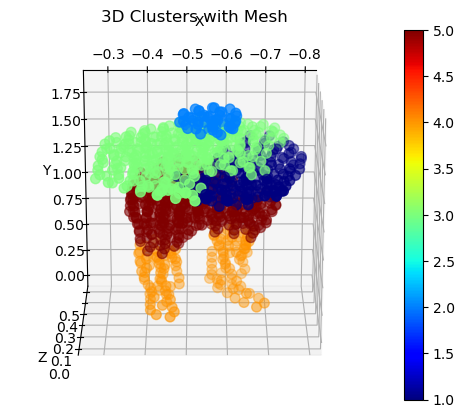

In [10]:


# Function to visualize points and clusters on a 3D model
def visualize_clusters_with_mesh(points, labels, obj_file_path):
    mesh = trimesh.load(obj_file_path)
    

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    

    mesh.show()  # Visualize the mesh

    scatter = ax.scatter(points[:, 0], points[:, 1], points[:, 2], c=labels, cmap='jet', s=50)
    plt.colorbar(scatter)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    # 
    # # rotate the axes and update
    # for angle in range(0, 360):
    #     ax.view_init(30, angle)
    #     plt.draw()
    #     plt.pause(.001)

    # Set the initial view angle
    ax.view_init(elev=-70, azim=90)  # Change these values to rotate

    plt.title("3D Clusters with Mesh")
    plt.show()
    
# write me function which will from the variable PUB_all_center_points get points from specific time step
def get_points_from_time_step(data, time_step):
    return data[time_step].reshape(-1, 3)

# Select points from a specific time step (for example, the first time step)
PUB_centers_points_first_mesh = get_points_from_time_step(PUB_all_center_points, 0)

# Visualize the clusters on the 3D model
visualize_clusters_with_mesh(PUB_centers_points_first_mesh, PUB_centers_labels, obj_file_path)


# Mapping to surface mesh

## Functions

In [6]:
import numpy as np
from scipy.spatial import KDTree

def create_categorized_surface_points(mesh, clustered_points, cluster_labels, num_surface_points=1000):
    """
    Categorize random points on the surface of a mesh based on the closest point inside the mesh.

    Parameters:
    - mesh_vertices: np.ndarray of shape (n_vertices, 3)
    - mesh_faces: np.ndarray of shape (n_faces, 3)
    - clustered_points: np.ndarray of shape (n_clustered_points, 3)
    - cluster_labels: np.ndarray of shape (n_clustered_points,)
    - num_surface_points: int, number of random points to generate on the surface

    Returns:
    - surface_points: np.ndarray of shape (num_surface_points, 3)
    - surface_labels: np.ndarray of shape (num_surface_points,)
    :param mesh: 
    """

    mesh_vertices = mesh.vertices
    mesh_faces = mesh.faces
    # Generate random points on the surface of the mesh
    surface_points = generate_random_points_on_mesh(mesh_vertices, mesh_faces, num_surface_points)

    # Build a KDTree for the clustered points
    kdtree = KDTree(clustered_points)

    # Find the closest clustered point for each surface point
    _, indices = kdtree.query(surface_points)

    # Assign the cluster label of the closest point to the surface point
    surface_labels = cluster_labels[indices]

    return surface_points, surface_labels

def generate_random_points_on_mesh(vertices, faces, num_points):
    """
    Generate random points on the surface of a mesh.

    Parameters:
    - vertices: np.ndarray of shape (n_vertices, 3)
    - faces: np.ndarray of shape (n_faces, 3)
    - num_points: int, number of random points to generate

    Returns:
    - points: np.ndarray of shape (num_points, 3)
    """
    # Compute the area of each face
    def triangle_area(v0, v1, v2):
        return 0.5 * np.linalg.norm(np.cross(v1 - v0, v2 - v0))

    areas = np.array([triangle_area(vertices[f[0]], vertices[f[1]], vertices[f[2]]) for f in faces])
    total_area = np.sum(areas)
    areas /= total_area

    # Select faces based on their area
    face_indices = np.random.choice(len(faces), size=num_points, p=areas)

    # Generate random points on the selected faces
    points = []
    for i in face_indices:
        f = faces[i]
        v0, v1, v2 = vertices[f[0]], vertices[f[1]], vertices[f[2]]
        r1, r2 = np.random.rand(2)
        if r1 + r2 > 1:
            r1, r2 = 1 - r1, 1 - r2
        point = (1 - r1 - r2) * v0 + r1 * v1 + r2 * v2
        points.append(point)

    return np.array(points)


## TEST - run

In [12]:

# Example usage

## Load the mesh
mesh = trimesh.load(obj_file_path)

centers_points = PUB_centers_points_first_mesh  # Replace with your clustered points inside the mesh
cluster_labels = PUB_centers_labels  # Replace with your cluster labels

surface_points, surface_labels = create_categorized_surface_points(mesh, centers_points, cluster_labels)

## Visualizing the surface points

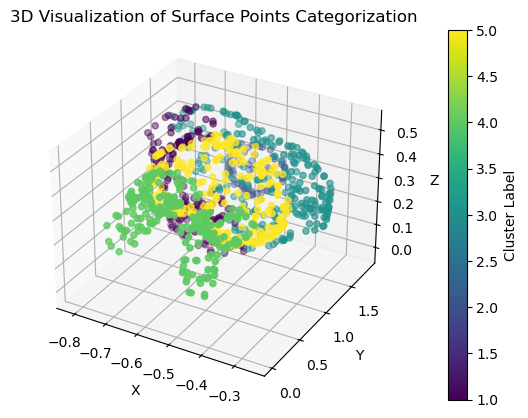

In [13]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def visualize_surface_points(points, labels):
    """
    Visualize the categorization of surface points in 3D.

    Parameters:
    points (numpy.ndarray): Array of 3D points with shape (n_points, 3).
    labels (numpy.ndarray): Array of cluster labels for each point with shape (n_points,).

    Returns:
    None
    """
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # Scatter plot with different colors for each cluster
    scatter = ax.scatter(points[:, 0], points[:, 1], points[:, 2], c=labels, cmap='viridis', marker='o')

    # Add color bar to show the cluster labels
    color_bar = plt.colorbar(scatter, ax=ax, pad=0.1)
    color_bar.set_label('Cluster Label')

    # Set labels for axes
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    # Set title
    ax.set_title('3D Visualization of Surface Points Categorization')

    # Show plot
    plt.show()
    
# Visualize the surface points
visualize_surface_points(surface_points, surface_labels)

# TEST - Map 2D to 3D surface

In [17]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [37]:
import cv2
import numpy as np

def map_texture_to_surface(image_path, points, triangles):
    """
    Maps a texture from a .jpg file to a 3D surface.

    Parameters:
    - image_path: str, path to the .jpg file
    - points: np.ndarray, array of 3D points (N x 3)
    - triangles: np.ndarray, array of triangle indices (M x 3)

    Returns:
    - textured_points: np.ndarray, array of 3D points with texture colors (N x 6)
    """
    # Load the image
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError("Image not found or unable to load.")

    # Normalize the points to the range of the image dimensions
    min_coords = points.min(axis=0)
    max_coords = points.max(axis=0)
    normalized_points = (points - min_coords) / (max_coords - min_coords)
    
    # Map the normalized points to the image dimensions
    image_height, image_width, _ = image.shape
    u_coords = (normalized_points[:, 0] * (image_width - 1)).astype(int)
    v_coords = (normalized_points[:, 1] * (image_height - 1)).astype(int)
    
    # Initialize an array to store the colors for each point
    colors = np.zeros((points.shape[0], 3), dtype=np.uint8)
    
    # Iterate over each triangle
    for triangle in triangles:
        # Get the vertex indices of the triangle
        v0, v1, v2 = triangle
        
        # Get the UV coordinates for each vertex
        uv0 = (u_coords[v0], v_coords[v0])
        uv1 = (u_coords[v1], v_coords[v1])
        uv2 = (u_coords[v2], v_coords[v2])
        
        # Get the colors from the image for each vertex
        color0 = image[uv0[1], uv0[0], :]
        color1 = image[uv1[1], uv1[0], :]
        color2 = image[uv2[1], uv2[0], :]
        
        # Assign the colors to the vertices
        colors[v0, :] = color0
        colors[v1, :] = color1
        colors[v2, :] = color2
    
    # Combine the points with their corresponding colors
    textured_points = np.hstack((points, colors))
    
    return textured_points

# Example usage

# get from surface_points and surface_labels lists of points in each cluster
PUB_centers_points_first_mesh = surface_points[surface_labels == 1]  # Cluster 0
# convert points to np.ndarray, array of 3D points (N x 3)
PUB_centers_points_first_mesh = np.array(PUB_centers_points_first_mesh)

# Example triangles array (M x 3)
triangles = np.array([
    [0, 1, 2],
    [2, 3, 0],
    # Add more triangles as needed
])

image_path = 'data/raw/2D_surface/squere.jpg'
textured_points = map_texture_to_surface(image_path, PUB_centers_points_first_mesh, triangles)

## Visualizing the textured surface

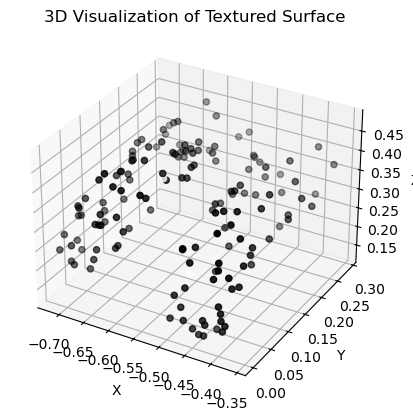

In [38]:
def visualize_textured_surface(points):
    """
    Visualize a 3D surface with texture colors.

    Parameters:
    - points: np.ndarray, array of 3D points with texture colors (N x 6)

    Returns:
    None
    """
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # Scatter plot with texture colors
    scatter = ax.scatter(points[:, 0], points[:, 1], points[:, 2], c=points[:, 3:] / 255, marker='o')

    # Set labels for axes
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    # Set title
    ax.set_title('3D Visualization of Textured Surface')

    # Show plot
    plt.show()
    
# Visualize the textured surface
visualize_textured_surface(textured_points)

In [39]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def map_texture_to_surface(image_path, points, triangles):
    """
    Maps a texture from a .jpg file to a 3D surface using barycentric interpolation.

    Parameters:
    - image_path: str, path to the .jpg file
    - points: np.ndarray, array of 3D points (N x 3)
    - triangles: np.ndarray, array of triangle indices (M x 3)

    Returns:
    - textured_surface: list of polygons with colors mapped for visualization.
    """
    # Load the image
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError("Image not found or unable to load.")

    image_height, image_width, _ = image.shape

    # Normalize the points to the range of the image dimensions
    min_coords = points.min(axis=0)
    max_coords = points.max(axis=0)
    normalized_points = (points - min_coords) / (max_coords - min_coords)

    # Map the normalized points to the image dimensions
    u_coords = (normalized_points[:, 0] * (image_width - 1)).astype(int)
    v_coords = (normalized_points[:, 1] * (image_height - 1)).astype(int)

    # Prepare the surface for visualization
    textured_surface = []

    # Iterate over each triangle
    for triangle in triangles:
        # Get the vertex indices of the triangle
        v0, v1, v2 = triangle

        # Get the 3D coordinates of the vertices
        p0, p1, p2 = points[v0], points[v1], points[v2]

        # Get the UV coordinates for each vertex
        uv0 = (u_coords[v0], v_coords[v0])
        uv1 = (u_coords[v1], v_coords[v1])
        uv2 = (u_coords[v2], v_coords[v2])

        # Extract the colors from the texture image for each vertex
        color0 = image[uv0[1], uv0[0], :] / 255.0  # Normalize to [0, 1] for RGB
        color1 = image[uv1[1], uv1[0], :] / 255.0
        color2 = image[uv2[1], uv2[0], :] / 255.0

        # Create a triangular surface element with color interpolation
        tri_verts = np.array([p0, p1, p2])
        tri_colors = np.array([color0, color1, color2])

        # Store triangle with vertices and colors
        textured_surface.append((tri_verts, tri_colors))

    return textured_surface

from scipy.spatial import Delaunay

def generate_triangles(points):
    """
    Generates triangles from a set of 3D points using Delaunay triangulation.

    Parameters:
    - points: np.ndarray, array of 3D points (N x 3)

    Returns:
    - triangles: np.ndarray, array of triangle indices (M x 3)
    """
    # Perform Delaunay triangulation
    delaunay = Delaunay(points[:, :2])  # Use only the x and y coordinates for 2D triangulation
    triangles = delaunay.simplices

    return triangles

#points = surface_points[surface_labels == 1]  # Cluster 0
#points = np.array(points)
#triangles = generate_triangles(points)

PUB_centers_points_first_mesh = mesh_vertices
triangles = mesh_faces


image_path = 'data/raw/2D_surface/squere.jpg'
textured_surface = map_texture_to_surface(image_path, PUB_centers_points_first_mesh, triangles)


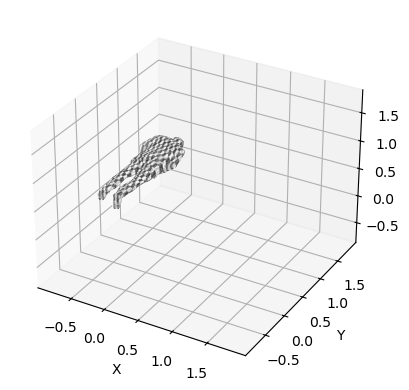

In [41]:
# Visualization function
def visualize_textured_surface(surface):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    for tri_verts, tri_colors in surface:
        # Create 3D polygons with vertex colors
        tri = Poly3DCollection([tri_verts], facecolors=[tri_colors.mean(axis=0)], edgecolor='none')
        ax.add_collection3d(tri)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    # Adjust the scale to fit the surface
    scale = np.concatenate([tri_verts for tri_verts, _ in surface]).flatten()
    ax.auto_scale_xyz(scale, scale, scale)

    plt.show()

visualize_textured_surface(textured_surface)

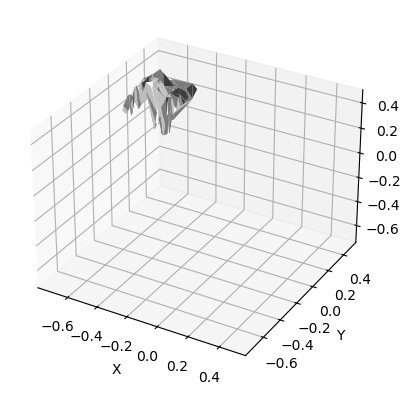

In [42]:
PUB_centers_points_first_mesh = surface_points[surface_labels == 1]  # Cluster 0
PUB_centers_points_first_mesh = np.array(PUB_centers_points_first_mesh)
triangles = generate_triangles(PUB_centers_points_first_mesh)

#points = mesh_vertices
#triangles = mesh_faces


image_path = 'data/raw/2D_surface/squere.jpg'
textured_surface = map_texture_to_surface(image_path, PUB_centers_points_first_mesh, triangles)

visualize_textured_surface(textured_surface)

## test UV

IndexError: index 800 is out of bounds for axis 1 with size 800

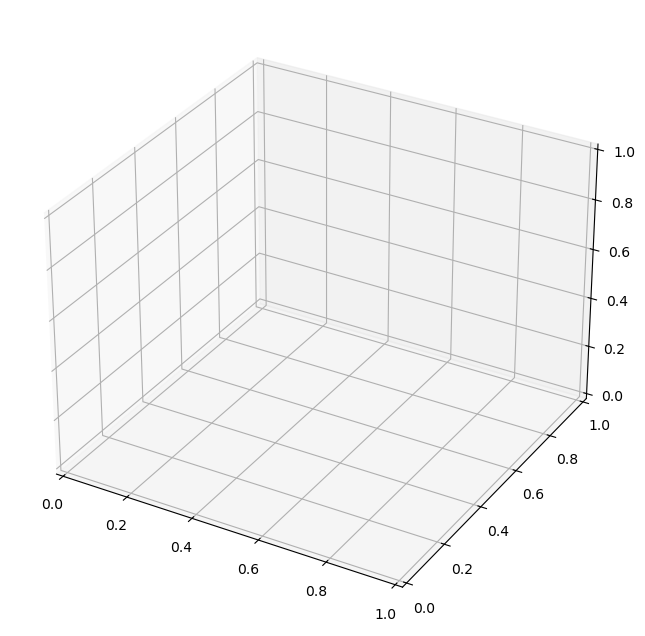

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from PIL import Image

def apply_uv_texture(mesh_points, mesh_faces, uv_coords, texture_image):
    """
    Maps a texture onto the given 3D mesh using UV coordinates.
    
    Parameters:
    mesh_points (ndarray): 3D coordinates of mesh vertices.
    mesh_faces (ndarray): Indices defining the triangular faces of the mesh.
    uv_coords (ndarray): UV coordinates for each vertex.
    texture_image (str): Path to the texture image file (.jpg).
    
    Returns:
    None. Displays the textured 3D mesh.
    """
    # Load the texture image
    img = Image.open(texture_image)
    img = np.array(img) / 255.0  # Normalize image values between 0 and 1

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Plot each face of the mesh and apply texture
    for face in mesh_faces:
        # Extract the vertices of the current face
        vert_points = mesh_points[face]

        # Extract corresponding UV coordinates
        uv_face = uv_coords[face]

        # Map the UV coordinates to the texture
        uv_img_coords = np.array([np.array(img.shape[1::-1]) * uv_face]).astype(int)
        texture_colors = img[uv_img_coords[:, 1], uv_img_coords[:, 0]]  # Get texture colors

        # Create polygon for the current face
        poly = Poly3DCollection([vert_points], facecolors=texture_colors.mean(axis=0), edgecolor='k')
        ax.add_collection3d(poly)

    # Set plot parameters
    ax.auto_scale_xyz([mesh_points[:, 0].min(), mesh_points[:, 0].max()],
                      [mesh_points[:, 1].min(), mesh_points[:, 1].max()],
                      [mesh_points[:, 2].min(), mesh_points[:, 2].max()])
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    plt.show()

import numpy as np

def calculate_uv_coords(mesh_points):
    """
    Calculates UV coordinates for mesh points using spherical projection.
    
    Parameters:
    mesh_points (ndarray): Array of 3D points of shape (N, 3).
    
    Returns:
    uv_coords (ndarray): UV coordinates of shape (N, 2).
    """
    # Extract x, y, z coordinates
    x, y, z = mesh_points[:, 0], mesh_points[:, 1], mesh_points[:, 2]

    # Calculate spherical coordinates (theta: latitude, phi: longitude)
    theta = np.arccos(z / np.linalg.norm(mesh_points, axis=1))  # Angle from Z-axis (0 to pi)
    phi = np.arctan2(y, x)  # Angle in XY plane (longitude, -pi to pi)

    # Normalize spherical coordinates to [0, 1] for UV mapping
    u = (phi + np.pi) / (2 * np.pi)  # Normalize longitude to [0, 1]
    v = theta / np.pi                # Normalize latitude to [0, 1]

    # Stack and return UV coordinates
    uv_coords = np.stack([u, v], axis=-1)
    return uv_coords


# Load the mesh vertices and faces
mesh_points = mesh.vertices
mesh_faces = mesh.faces
uv_coords = calculate_uv_coords(mesh_points)
image_path = 'data/raw/2D_surface/squere.jpg'
apply_uv_texture(mesh_points, mesh_faces, uv_coords, image_path)

# TEST - Other types of clustering
## DBSCAN clustering


In [ ]:
### Clustering

In [41]:



# Perform hierarchical clustering using precomputed distances
PUB_centers_labels = dbscan_clustering_from_precomputed_distances(max_distances, 0.2, 5)
print("Clustering completed.")


Clustering completed.


### Visualization

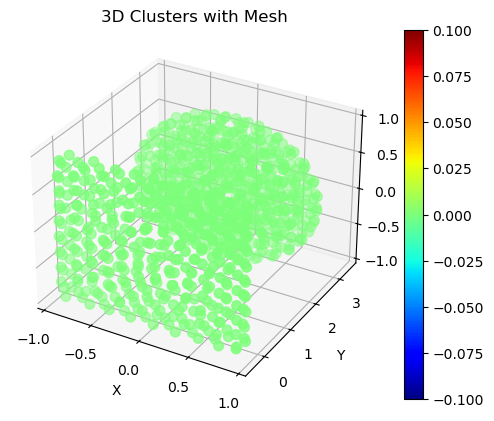

In [42]:
# Select points from a specific time step (for example, the first time step)
PUB_centers_points_first_mesh = PUB_all_center_points[0].reshape(-1, 3)  # Reshape into list of 3D points

# Visualize the clusters on the 3D model
visualize_clusters_with_mesh(PUB_centers_points_first_mesh, PUB_centers_labels, obj_file_path)


## Hierarchical clustering 2


### Clustering

In [ ]:

# Function for hierarchical clustering using precomputed distances
def hierarchical_clustering_from_precomputed_distances(distances, n_clusters=4, method='ward'):
    #condensed_distances = squareform(distances)
    condensed_distances = distances[np.triu_indices(distances.shape[0], k=1)]
    Z = linkage(condensed_distances, method=method)
    labels = fcluster(Z, n_clusters, criterion='maxclust')
    return labels

# Perform hierarchical clustering using precomputed distances
num_clusters = 2  # Adjust as needed
PUB_centers_labels = hierarchical_clustering_from_precomputed_distances(max_distances, n_clusters=num_clusters)
print("Hierarchical clustering completed.")

### Visualization

In [ ]:
# Select points from a specific time step (for example, the first time step)
PUB_centers_points_first_mesh = PUB_all_center_points[0].reshape(-1, 3)  # Reshape into list of 3D points

# Visualize the clusters on the

# Neural network

## Prepare data for neural network

### Functions

In [11]:
import json
import os

# create surface points for all meshes

def get_filepaths_from_json(folder_path, json_file_path):
    """
    Load the file paths from the JSON file and add the folder path as a prefix.

    Parameters:
    - folder_path: str, the folder path to be prefixed
    - json_file_path: str, path to the JSON file

    Returns:
    - meshes_filepaths_list: list of str, list of file paths with the folder path prefixed
    """
    with open(json_file_path, 'r') as file:
        data = json.load(file)
    
    meshes_filepaths_list = []
    for pair in data['pairs']:
        mesh_file_path = os.path.join(folder_path, pair['mesh_filename'])
        meshes_filepaths_list.append(mesh_file_path)
    
    return meshes_filepaths_list

class SurfaceDataList:
    def __init__(self, surface_data_list):
        if not all(isinstance(item, SurfaceData) for item in surface_data_list):
            raise TypeError("All items in surface_data_list must be instances of SurfaceData")
        self.list = surface_data_list

    def create_surface_points_from_mesh_list(self, meshes_filepaths_list, center_points_list, cluster_center_labels, num_surface_points):
        """
        Create surface points for each mesh in the list.
    
        Parameters:
        - meshes_filepaths_list: list of str, list of file paths to the meshes
    
        Returns:
        - surface_points_list: list of np.ndarray, list of surface points for each mesh
        """
        surface_data_list = SurfaceDataList([])
        for i, mesh_file_path in enumerate(meshes_filepaths_list):
            print("Creating surface points for mesh " + str(i + 1) + " of " + str(len(meshes_filepaths_list)))
            mesh = trimesh.load(mesh_file_path)
            centers_points = center_points_list[i]
            surface_points, surface_labels = create_categorized_surface_points(mesh, centers_points, cluster_center_labels, num_surface_points)
            #append both values to list with names in the list
            surface_data_list.append(SurfaceData(surface_points, surface_labels, None))

        self.list = surface_data_list.list
        # add time function
    def add_time(surface_data_list):
        for i, surface_data in enumerate(surface_data_list.list):
            if surface_data.time is not None:
                Exception("Time already added")
                break

            surface_data.time = i
        surface_data_list.list = surface_data_list.list
        # normalize the data
    def normalize(surface_data_list):
        """
        Normalize the surface points for all objects in the list.
        it will normalize the data to the range [0, 1] for each axis.
        and shifts the data to the origin of 0, 0, 0
        :return:  normalized_surface_points: SurfaceDataList
        """
        def normalize_time(time, length):
            length = length - 1
            new_time = time / length
            #print all velues
            print("Time: ", time, "Length: ", length, "New time: ", new_time)
            return new_time

        def scale_object_points(object_points, norm):
            return object_points / norm

        def shift_object_points_to_origin(object_points, shift_vector):
            return object_points - shift_vector

        def normalize_object_points(object_points, norm, shift_vector):
            object_points = shift_object_points_to_origin(object_points, shift_vector)
            object_points = scale_object_points(object_points, norm)
            return object_points

        # Calculate the bounding box for all objects combined
        all_points = np.vstack([surface_data.surface_points for surface_data in surface_data_list.list])
        min_corner = np.min(all_points, axis=0)
        shift_vector = min_corner  # Shift all objects to the position of the minimum corner

        # Calculate the maximum norm of all points across all axes for each object
        max_norm = max(np.linalg.norm(surface_data_element.surface_points, ord=None, axis=None).max() for surface_data_element in surface_data_list.list)

        normalized_surface_points = SurfaceDataList([])
        for surface_data in surface_data_list.list:
            print("Normalizing surface points for time step " + str(surface_data.time))
            normalized_time = normalize_time(surface_data.time, len(surface_data_list.list))
            normalized_points = normalize_object_points(surface_data.surface_points, max_norm, shift_vector)
            normalized_surface_points.append(SurfaceData(normalized_points, surface_data.surface_labels, normalized_time))

        surface_data_list.list = normalized_surface_points.list


    def prepare_data(self, meshes_filepaths_list, center_points_list, cluster_center_labels, num_surface_points):
        
        print("Creating surface points for all meshes...")
        self.create_surface_points_from_mesh_list(meshes_filepaths_list, center_points_list, cluster_center_labels, num_surface_points)
        self.add_time()
        self.normalize()
    
    # append function
    def append(self, surface_data):
        # check if surface_data is instance of SurfaceData
        if not isinstance(surface_data, SurfaceData):
            raise TypeError("surface_data must be an instance of SurfaceData")
        self.list.append(surface_data)

    
        
    

class SurfaceData:
    def __init__(self, surface_points, surface_labels, time):
        self.surface_points = surface_points
        self.surface_labels = surface_labels
        self.time = time




### run

In [8]:

def pipeline_data_prepare():
    global folder_path_meshes, json_file_path, max_distances, center_points_list, num_clusters, cluster_center_labels
    folder_path_meshes = PUB_data_folder_path
    json_file_path = PUB_data_folder_path + "center_mesh_pairs.json"
    max_distances, center_points_list = load_data(PUB_data_folder_path, 'bin')
    # Perform hierarchical clustering using precomputed distances
    num_clusters = 5  # Adjust as needed
    cluster_center_labels = hierarchical_clustering_from_precomputed_distances(max_distances, n_clusters=num_clusters)


pipeline_data_prepare()

Loading .bin files...
Loading file 1 of 10
Loading file 2 of 10
Loading file 3 of 10
Loading file 4 of 10
Loading file 5 of 10
Loading file 6 of 10
Loading file 7 of 10
Loading file 8 of 10
Loading file 9 of 10
Loading file 10 of 10
computing max distances1
computing max distances2
computing max distances3
computing max distances4
computing max distances5
computing max distances6
computing max distances7
computing max distances8
computing max distances9
computing max distances10
Max distances computed between all pairs of points.


In [13]:

meshes_filepaths_list = get_filepaths_from_json(folder_path_meshes, json_file_path)
print("Creating surface points for all meshes...")
PUB_surface_data_list = SurfaceDataList([])
PUB_surface_data_list.create_surface_points_from_mesh_list(meshes_filepaths_list, center_points_list, cluster_center_labels, 1000)
"""list of tuples with surface points and labels for all meshes specified in config json file"""

Creating surface points for all meshes...
Creating surface points for mesh 1 of 5
Creating surface points for mesh 2 of 5
Creating surface points for mesh 3 of 5
Creating surface points for mesh 4 of 5
Creating surface points for mesh 5 of 5


'list of tuples with surface points and labels for all meshes specified in config json file'

In [18]:
internal_value = PUB_surface_data_list
internal_value.add_time()
internal_value.normalize()
print("Surface points created and normalized.")

AttributeError: 'SurfaceDataList' object has no attribute 'copy'

## Neural network model by cluster

In [ ]:

import torch.optim as optim

import numpy as np
import torch
from torch.utils.data import Dataset

class SurfaceDataset(Dataset):
    def __init__(self, surface_data_list):
        self.data = []
        for surface_data in surface_data_list:
            points = surface_data.surface_points
            time = np.full((points.shape[0], 1), surface_data.time)
            points_with_time = np.hstack((points, time))
            self.data.append(points_with_time)
        self.data = np.vstack(self.data)
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return self.data[idx, :], self.data[idx, :]
    
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(4, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        )
        self.decoder = nn.Sequential(
            nn.Linear(3, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 4)
        )
    
    def forward(self, x):
        time_value = x[:, 3].unsqueeze(1)  # Extract time value and keep it as a column vector
        encoded_features = self.encoder(x)
        encoded_with_time = torch.cat((encoded_features, time_value), dim=1)  # Concatenate encoded features with time
        decoded_output = self.decoder(encoded_with_time)
        return decoded_output

def train_neural_network(data, num_epochs=100):
    
    # Create dataset and dataloader
    dataset = SurfaceDataset(data)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)
    # Initialize model, loss function, and optimizer
    model = MLP()
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    # Training loop
    for epoch in range(num_epochs):
        for inputs, targets in dataloader:
            inputs, targets = inputs.float(), targets.float()

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')


In [ ]:
# select one cluster from data
surface_data_cluster_0 = [surface_data for surface_data in PUB_surface_data_list.list if surface_data.surface_labels == 0]

train_neural_network(surface_data_cluster_0)